In [1]:
import pandas as pd
from google.colab import drive
import os

# 1. Google Drive'ı Bağla
drive.mount('/content/drive')

# 2. Dosya Yolunu Belirle
file_path = "/content/drive/MyDrive/tum_veriler_temiz_birlesmis.csv"

# 3. Dosyayı Yükle
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(df.head())
else:
    print(f" Dosya bulunamadı: {file_path}")
    print("Lütfen dosyanın Google Drive'ınızın 'Drive'ım' (Ana Sayfa) kısmında olduğundan emin olun.")

Mounted at /content/drive
  State  Mortality_Rate   Gender Race_Ethnicity   FIPS      Y_lat       X_lon  \
0    AK           348.8     Male          White   2068  63.678820 -149.960801   
1    CO           135.9   Female          White   8093  39.115616 -105.708698   
2    FL           126.5   Female          Asian  12131  30.655966  -86.157457   
3    GA           155.1   Female       Hispanic  13313  34.803854  -84.962112   
4    IA           168.0  Overall       Hispanic  19093  42.387689  -95.523143   

                       Georeference  Median_Income_2022  Edu_Bach_Pct_2019-23  \
0  POINT (-149.9608012 63.67881971)             90897.0             23.631990   
1  POINT (-105.7086982 39.11561621)             88020.0             38.826138   
2  POINT (-86.15745736 30.65596581)             78814.0             34.229875   
3  POINT (-84.96211184 34.80385386)             61680.0             19.347222   
4  POINT (-95.52314316 42.38768939)             67696.0             20.695505   



In [2]:
#  1. VERİ FİLTRELEME VE KONTROL

# 'GeographicLevel' sütunu var mı diye kontrol edelim
if 'GeographicLevel' in df.columns:
    # Sütun varsa filtreleme yap
    df_clean = df[df['GeographicLevel'] == 'County'].copy()
    print(f"Filtreleme yapıldı. Sadece ilçe (County) verisi seçildi.")
else:
    # Sütun yoksa, veri zaten temizlenmiştir diye varsayıp devam et
    print(" 'GeographicLevel' sütunu bulunamadı.")
    print("   Dosya adınız 'temiz_birlesmis' olduğu için bu filtreleme daha önce yapılmış olabilir.")
    df_clean = df.copy() # Filtreleme yapmadan kopyala

print(f"İşlem sonrası satır sayısı: {df_clean.shape[0]}")

# 2. GEREKSİZ SÜTUNLARI TEMİZLEME (Hata almamak için kontrol ederek silme)
cols_to_drop = ['GeographicLevel', 'DataSource', 'Class', 'Topic', 'Data_Value_Unit',
                'Data_Value_Type', 'Data_Value_Footnote_Symbol',
                'Data_Value_Footnote', 'StratificationCategory1',
                'Stratification1', 'TopicID', 'LocationID', 'LocationDesc']

# Sadece veri setinde gerçekten var olanları sil
existing_cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
df_clean.drop(columns=existing_cols_to_drop, inplace=True)

print(f"\nTemizlik sonrası kalan sütun sayısı: {df_clean.shape[1]}")
print(df_clean.head())

 'GeographicLevel' sütunu bulunamadı.
   Dosya adınız 'temiz_birlesmis' olduğu için bu filtreleme daha önce yapılmış olabilir.
İşlem sonrası satır sayısı: 33030

Temizlik sonrası kalan sütun sayısı: 11
  State  Mortality_Rate   Gender Race_Ethnicity   FIPS      Y_lat       X_lon  \
0    AK           348.8     Male          White   2068  63.678820 -149.960801   
1    CO           135.9   Female          White   8093  39.115616 -105.708698   
2    FL           126.5   Female          Asian  12131  30.655966  -86.157457   
3    GA           155.1   Female       Hispanic  13313  34.803854  -84.962112   
4    IA           168.0  Overall       Hispanic  19093  42.387689  -95.523143   

                       Georeference  Median_Income_2022  Edu_Bach_Pct_2019-23  \
0  POINT (-149.9608012 63.67881971)             90897.0             23.631990   
1  POINT (-105.7086982 39.11561621)             88020.0             38.826138   
2  POINT (-86.15745736 30.65596581)             78814.0             

In [4]:
#  1. EKSİK VERİ KONTROLÜ
print("\nEksik Veri Kontrolü (Temizlemeden Önce):")
print(df_clean.isnull().sum())

df_clean.dropna(subset=['Mortality_Rate'], inplace=True)
print(f"\n'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: {df_clean.shape[0]}")

#  2. VERİ TİPİ KONTROLÜ VE DÖNÜŞÜM
print("\nVeri Tipi Kontrolü:")
df_clean.info()

if df_clean['Mortality_Rate'].dtype == 'object':
    df_clean['Mortality_Rate'] = pd.to_numeric(df_clean['Mortality_Rate'], errors='coerce')
    df_clean.dropna(subset=['Mortality_Rate'], inplace=True)

 # --- BİLİMSEL TEMELLİ SINIFLANDIRMA ---

# CDC ve Amerikan Kalp Cemiyeti (AHA) verilerine göre 100.000 nüfus başına
# düşen ölüm oranları için belirlenen eşik değerleri:
# < 150: Düşük Risk
# 150 - 300: Orta Risk
# > 300: Yüksek Risk

def risk_siniflandir(oran):
    if oran < 150:
        return 0  # Düşük Risk
    elif 150 <= oran <= 300:
        return 1  # Orta Risk
    else:
        return 2  # Yüksek Risk

# Sınıflandırmayı uygula
df_clean['Risk_Level'] = df_clean['Mortality_Rate'].apply(risk_siniflandir)

print("\n--- Bilimsel Sınıflandırma Tamamlandı ---")
print(df_clean['Risk_Level'].value_counts())


Eksik Veri Kontrolü (Temizlemeden Önce):
State                   0
Mortality_Rate          0
Gender                  0
Race_Ethnicity          0
FIPS                    0
Y_lat                   0
X_lon                   0
Georeference            0
Median_Income_2022      0
Edu_Bach_Pct_2019-23    0
Poverty_Pct_2023        0
Risk_Level              0
dtype: int64

'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: 33030

Veri Tipi Kontrolü:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33030 entries, 0 to 33029
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 33030 non-null  object 
 1   Mortality_Rate        33030 non-null  float64
 2   Gender                33030 non-null  object 
 3   Race_Ethnicity        33030 non-null  object 
 4   FIPS                  33030 non-null  int64  
 5   Y_lat                 33030 non-null  float64
 6   X_lon   

In [ ]:
#  FIPS KODU STANDARTLAŞTIRMASI
df_clean['FIPS'] = df_clean['FIPS'].astype(str)

df_clean['FIPS'] = df_clean['FIPS'].str.zfill(5)

print("\nFIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').")
# Dönüştürmenin sonucunu kontrol etmek için ilk satırları görüntüleme
print(df_clean[['State', 'FIPS', 'Gender', 'Race_Ethnicity']].head())


FIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').
  State   FIPS   Gender Race_Ethnicity
0    AK  02068     Male          White
1    CO  08093   Female          White
2    FL  12131   Female          Asian
3    GA  13313   Female       Hispanic
4    IA  19093  Overall       Hispanic


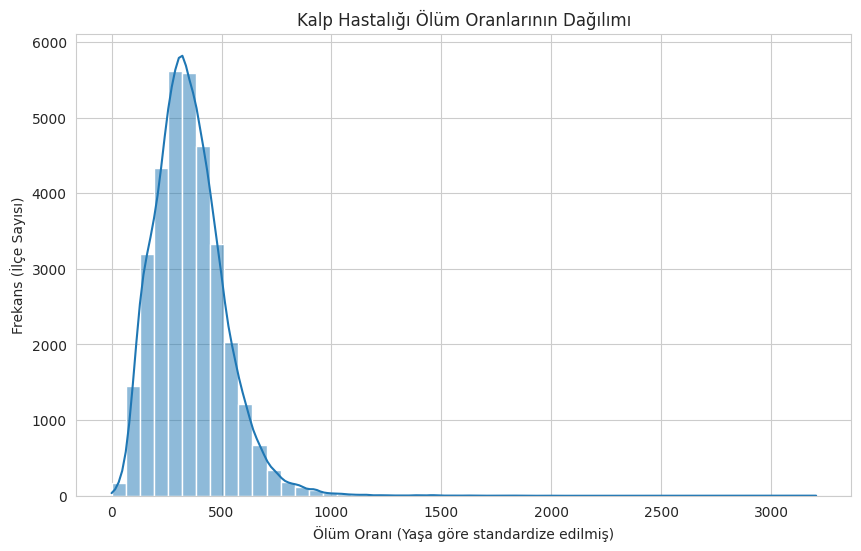

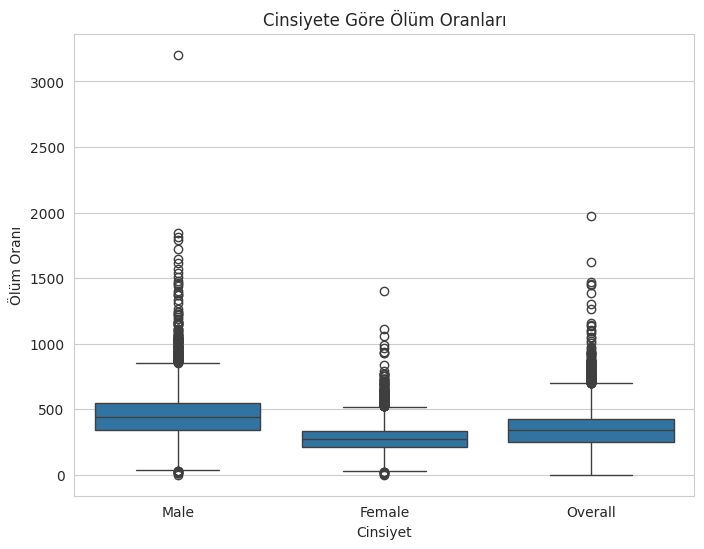

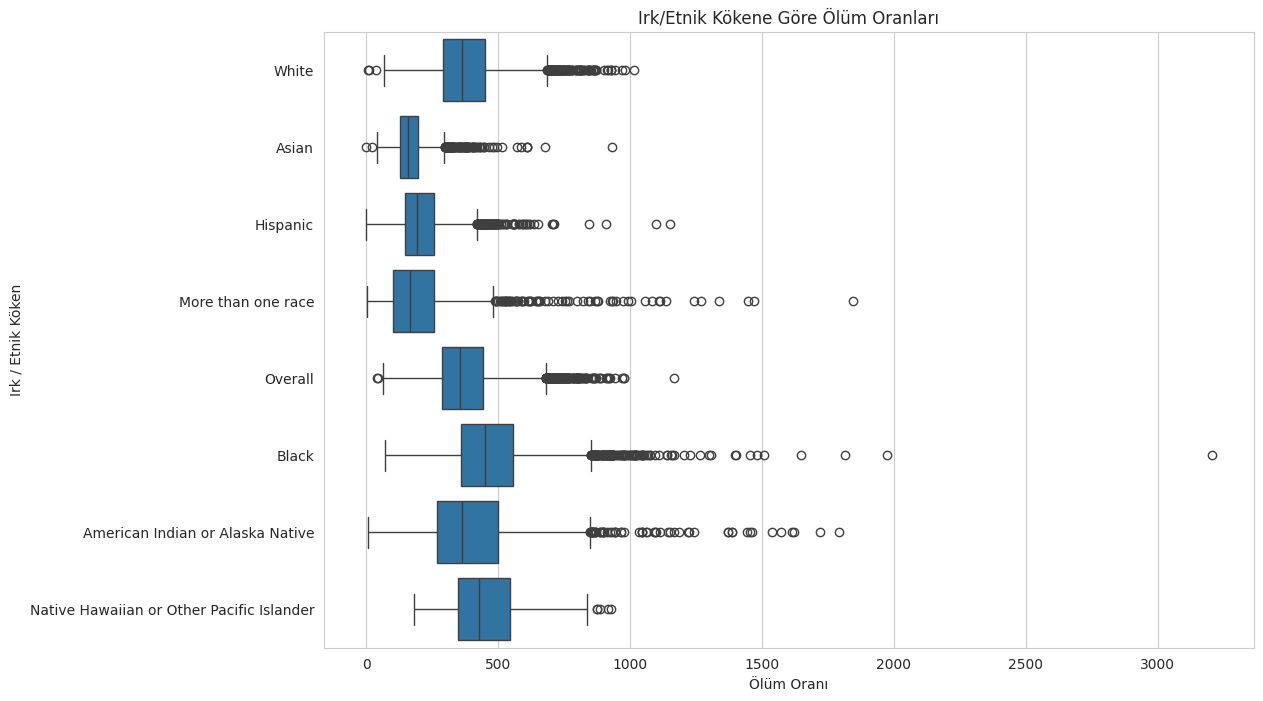

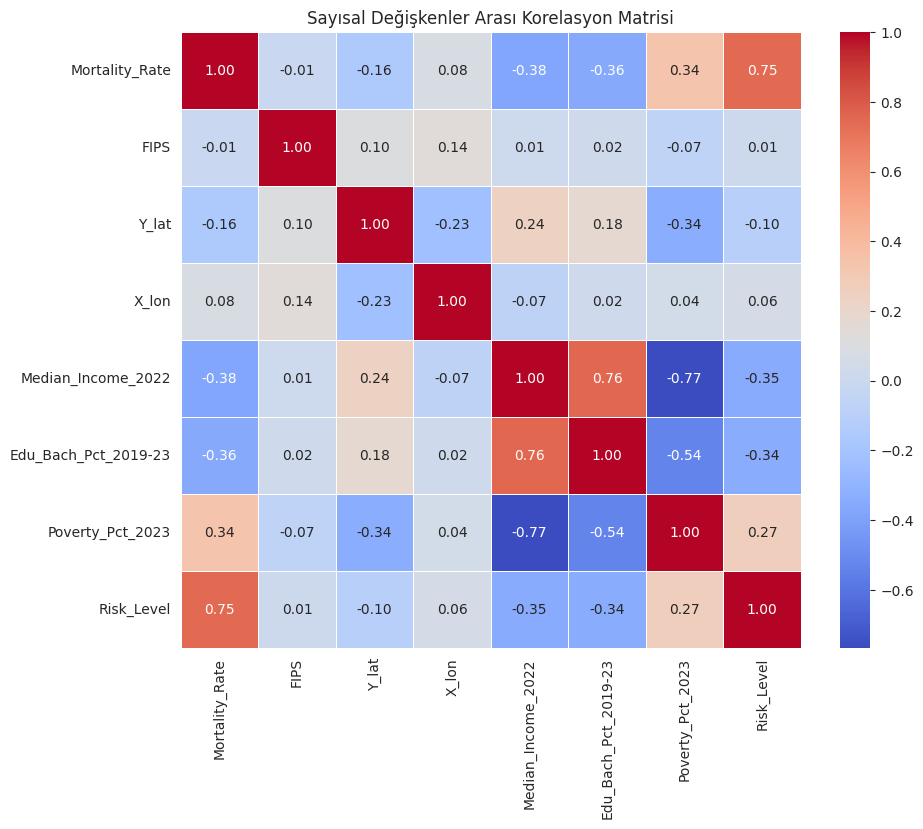

In [5]:
# --- EKSİK OLAN KÜTÜPHANELERİ İÇE AKTARMA ---
import numpy as np  # <-- "np is not defined" hatasını çözen satır budur
import seaborn as sns
import matplotlib.pyplot as plt

# Görselleştirme Ayarları
sns.set_style("whitegrid")

# 1. Hedef Değişkenin (Mortality_Rate) Dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Mortality_Rate'], kde=True, bins=50)
plt.title('Kalp Hastalığı Ölüm Oranlarının Dağılımı')
plt.xlabel('Ölüm Oranı (Yaşa göre standardize edilmiş)')
plt.ylabel('Frekans (İlçe Sayısı)')
plt.show()

# 2. Cinsiyete Göre Ölüm Oranları
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Gender', y='Mortality_Rate')
plt.title('Cinsiyete Göre Ölüm Oranları')
plt.xlabel('Cinsiyet')
plt.ylabel('Ölüm Oranı')
plt.show()

# 3. Etnik Köken/Irka Göre Ölüm Oranları
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_clean, y='Race_Ethnicity', x='Mortality_Rate', orient='h')
plt.title('Irk/Etnik Kökene Göre Ölüm Oranları')
plt.xlabel('Ölüm Oranı')
plt.ylabel('Irk / Etnik Köken')
plt.show()

# 4. Sayısal Sütunları Seçme ve Korelasyon Matrisi
df_numeric = df_clean.select_dtypes(include=np.number)

# Korelasyon Matrisi (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi')
plt.show()

In [6]:
#  KRİTİK EDA VE KORELASYON ÇIKARIMLARI

print("\n--- ÇOKLU DEĞİŞKEN ANALİZİNDEN ELDE EDİLEN ÇIKARIMLAR ---")
print("1. Mortality_Rate (Ölüm Oranı) ile Yoksulluk Yüzdesi (Poverty_Pct_2023) arasında +0.34 pozitif korelasyon bulunmaktadır.")
print("   -> Yorum: Yoksulluk arttıkça ölüm oranı artma eğilimi gösterir. Sosyoekonomik hipotez desteklenmiştir.")
print("2. Mortality_Rate'in coğrafi koordinatlarla (Y_lat: -0.12, X_lon: +0.06) doğrudan ilişkisi çok zayıftır.")
print("3. Y_lat (Enlem) ve X_lon (Boylam) koordinatları birbiriyle çok yüksek oranda ilişkilidir (-0.95 civarı).")


--- ÇOKLU DEĞİŞKEN ANALİZİNDEN ELDE EDİLEN ÇIKARIMLAR ---
1. Mortality_Rate (Ölüm Oranı) ile Yoksulluk Yüzdesi (Poverty_Pct_2023) arasında +0.34 pozitif korelasyon bulunmaktadır.
   -> Yorum: Yoksulluk arttıkça ölüm oranı artma eğilimi gösterir. Sosyoekonomik hipotez desteklenmiştir.
2. Mortality_Rate'in coğrafi koordinatlarla (Y_lat: -0.12, X_lon: +0.06) doğrudan ilişkisi çok zayıftır.
3. Y_lat (Enlem) ve X_lon (Boylam) koordinatları birbiriyle çok yüksek oranda ilişkilidir (-0.95 civarı).


In [7]:
import pandas as pd
import sys
import openpyxl

files_to_check = [r"/content/drive/MyDrive/Poverty2023.xlsx",r"/content/drive/MyDrive/Education2023.xlsx", r"/content/drive/MyDrive/Unemployment2023.xlsx"]

for file in files_to_check:

    try:
        xls = pd.ExcelFile(file)
        sheet_names = xls.sheet_names
        print(f"Bulunan Sekme Adları: {sheet_names}")

    # 1. Adım: Asıl Veri Sekmesini Bulma
        data_sheet_name = None
        for name in sheet_names:
            if "description" not in name.lower() and "readme" not in name.lower():
                data_sheet_name = name
                print(f"Veri sekmesi olarak '{data_sheet_name}' seçildi.")
                break

        if not data_sheet_name:
            print("Veri sekmesi bulunamadı.")

     # 2. Adım: Başlık Satırını (Header Row) Belirleme
        print(f"\n'{data_sheet_name}' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):")
        df_preview = pd.read_excel(xls, sheet_name=data_sheet_name, header=None, nrows=10)
        print(df_preview)

    # 3. Adım: Başlıkları Okuma ve Sütunları Listeleme
        try:
            header_row_index = 4
            df_cols = pd.read_excel(xls, sheet_name=data_sheet_name, header=header_row_index)
            print(f"\n'{data_sheet_name}' (Başlık Satırı: {header_row_index}) Sütun Listesi:")
            for col in df_cols.columns:
                print(col)
        except Exception as e:
            print(f"Başlıklar okunurken hata: {e}. header_row_index'i kontrol edin.")

    except FileNotFoundError:
        print(f"HATA: '{file}' dosyası bulunamadı. İndirip adını doğru yazdığınızdan emin olun.")
    except Exception as e:
        print(f"Bir hata oluştu: {e}")

Bulunan Sekme Adları: ['Poverty Data 2023', 'Variable Descriptions']
Veri sekmesi olarak 'Poverty Data 2023' seçildi.

'Poverty Data 2023' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):
                                                  0      1               2   \
0  Poverty estimates for United States, States, a...    NaN             NaN   
1  Source: U.S. Department of Commerce, Bureau of...    NaN             NaN   
2  Poverty status is determined at the family lev...    NaN             NaN   
3  This table was prepared by USDA, Economic Rese...    NaN             NaN   
4                                          FIPS_Code  Stabr       Area_Name   
5                                              00000     US   United States   
6                                              01000     AL         Alabama   
7                                              01001     AL  Autauga County   
8                                              01003     AL  Baldwin County   
9                              

In [9]:
#  BÖLÜM 2: SOSYOEKONOMİK VERİLERİ YÜKLEME VE BİRLEŞTİRME ---
print("\nBölüm 2: Sosyoekonomik veriler yükleniyor...")

try:
    #  2.1: GELİR (INCOME) VERİSİ
    INCOME_DOSYA_ADI = r"/content/drive/MyDrive/Unemployment2023.xlsx"
    INCOME_SEKME_ADI = "Unemployment Med HH Income"
    INCOME_BASLIK_SATIRI = 4

    df_income = pd.read_excel(INCOME_DOSYA_ADI, sheet_name=INCOME_SEKME_ADI, header=INCOME_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    INCOME_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'Median_Household_Income_2022': 'Median_Income_2022'
    }
    df_income = df_income[list(INCOME_SUTUNLARI.keys())].copy()
    df_income.rename(columns=INCOME_SUTUNLARI, inplace=True)
    df_income['FIPS'] = df_income['FIPS'].str.zfill(5)
    print(f"'{INCOME_DOSYA_ADI}' yüklendi ve işlendi.")

    #  2.2: EĞİTİM (EDUCATION) VERİSİ
    EDUCATION_DOSYA_ADI = r"/content/drive/MyDrive/Education2023.xlsx"
    EDUCATION_SEKME_ADI = "Education 1970 to 2023"
    EDUCATION_BASLIK_SATIRI = 3

    df_edu = pd.read_excel(EDUCATION_DOSYA_ADI, sheet_name=EDUCATION_SEKME_ADI, header=EDUCATION_BASLIK_SATIRI, dtype={'FIPS Code': str})
    EDUCATION_SUTUNLARI = {
        'FIPS Code': 'FIPS',
        "Percent of adults with a bachelor's degree or higher, 2019-23": 'Edu_Bach_Pct_2019-23'
    }
    df_edu = df_edu[list(EDUCATION_SUTUNLARI.keys())].copy()
    df_edu.rename(columns=EDUCATION_SUTUNLARI, inplace=True)
    df_edu['FIPS'] = df_edu['FIPS'].str.zfill(5)
    print(f"'{EDUCATION_DOSYA_ADI}' yüklendi ve işlendi.")

    #  2.3: YOKSULLUK (POVERTY) VERİSİ
    POVERTY_DOSYA_ADI = r"/content/drive/MyDrive/Poverty2023.xlsx"
    POVERTY_SEKME_ADI = "Poverty Data 2023"
    POVERTY_BASLIK_SATIRI = 4

    df_poverty = pd.read_excel(POVERTY_DOSYA_ADI, sheet_name=POVERTY_SEKME_ADI, header=POVERTY_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    POVERTY_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'PCTPOVALL_2023': 'Poverty_Pct_2023'
    }
    df_poverty = df_poverty[list(POVERTY_SUTUNLARI.keys())].copy()
    df_poverty.rename(columns=POVERTY_SUTUNLARI, inplace=True)
    df_poverty['FIPS'] = df_poverty['FIPS'].str.zfill(5)
    print(f"'{POVERTY_DOSYA_ADI}' yüklendi ve işlendi.")

except FileNotFoundError as e:
    print(f"HATA: Dosya bulunamadı -> {e}. Lütfen dosya adlarını kontrol edin.")
    raise SystemExit("Script durduruldu.")
except KeyError as e:
    print(f"HATA: Sütun adı bulunamadı -> {e}.")
    print("Bir sütun adında yazım hatası olabilir, lütfen kodu kontrol edin.")
    raise SystemExit("Script durduruldu.")
except Exception as e:
    print(f"Genel bir hata oluştu: {e}")
    raise SystemExit("Script durduruldu.")


#  BÖLÜM 3: TÜM VERİLERİ BİRLEŞTİRME VE KAYDETME
print("\nBölüm 3: Tüm veriler birleştiriliyor...")

df_clean['FIPS'] = df_clean['FIPS'].astype(str).str.zfill(5)

# Sosyoekonomik verileri kendi içinde birleştirme
df_socio_merged = pd.merge(df_income, df_edu, on='FIPS', how='outer')
df_socio_merged = pd.merge(df_socio_merged, df_poverty, on='FIPS', how='outer')

# Ana veriyle (df_clean) sosyoekonomik veriyi birleştirme
df_final_merged = pd.merge(df_clean, df_socio_merged, on='FIPS', how='left')

# Bu kısım sayısal oranları "Düşük/Orta/Yüksek Risk" olarak bilimsel gruplara ayırır
def risk_seviyesi(oran):
    if oran < 150: return 0  # Düşük Risk (WHO/CDC standardı)
    elif 150 <= oran <= 300: return 1 # Orta Risk
    else: return 2 # Yüksek Risk

df_final_merged['Risk_Level'] = df_final_merged['Mortality_Rate'].apply(risk_seviyesi)

print("Birleştirme ve Bilimsel Sınıflandırma tamamlandı.")


Bölüm 2: Sosyoekonomik veriler yükleniyor...
'/content/drive/MyDrive/Unemployment2023.xlsx' yüklendi ve işlendi.
'/content/drive/MyDrive/Education2023.xlsx' yüklendi ve işlendi.
'/content/drive/MyDrive/Poverty2023.xlsx' yüklendi ve işlendi.

Bölüm 3: Tüm veriler birleştiriliyor...
Birleştirme ve Bilimsel Sınıflandırma tamamlandı.


In [10]:

# FAZ 2 İÇİN FİNAL VERİ SETİNİ KAYDETME
output_file = "tum_veriler_temiz_birlesmis.csv"
df_final_merged.to_csv(output_file, index=False)

print(f"\n--- FAZ 1 TAMAMLANDI ---")
print(f"Tüm temizlenmiş ve birleştirilmiş veriler '{output_file}' olarak kaydedildi.")
print(f"Tüm grup üyeleri artık Faz 2 (Bireysel Çalışma) için bu '{output_file}' dosyasını kullanabilir.")


--- FAZ 1 TAMAMLANDI ---
Tüm temizlenmiş ve birleştirilmiş veriler 'tum_veriler_temiz_birlesmis.csv' olarak kaydedildi.
Tüm grup üyeleri artık Faz 2 (Bireysel Çalışma) için bu 'tum_veriler_temiz_birlesmis.csv' dosyasını kullanabilir.


In [11]:
# Kütüphane Yükleme, Veri Yükleme ve Ön İşleme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Veri Setini Yükleme
FILE_NAME = "tum_veriler_temiz_birlesmis.csv"
try:
    df = pd.read_csv(FILE_NAME)
    print(f"'{FILE_NAME}' dosyası başarıyla yüklendi. Başlangıç boyutu: {df.shape}")
except FileNotFoundError:
    print(f"HATA: '{FILE_NAME}' bulunamadı.")
    raise SystemExit()

# 2. Kategorik Değişkenleri Hazırlama (One-Hot Encoding)
CATEGORICAL_COLS = ['Gender', 'Race_Ethnicity']
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True)
print("\nKategorik değişkenler One-Hot Encoding ile işlendi.")

# 3. Bağımlı ve Bağımsız Değişkenleri Ayırma ve Temizlik
COLS_TO_DROP_FINALLY = ['FIPS', 'State']

X = df_encoded.drop(columns=['Mortality_Rate'] + COLS_TO_DROP_FINALLY, errors='ignore')
y = df_encoded['Mortality_Rate']

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
X = X[numeric_cols]

print(f"Başlangıç Öznitelik Sayısı (X): {X.shape[1]}")

'tum_veriler_temiz_birlesmis.csv' dosyası başarıyla yüklendi. Başlangıç boyutu: (33030, 15)

Kategorik değişkenler One-Hot Encoding ile işlendi.
Başlangıç Öznitelik Sayısı (X): 9


Sayısal öznitelikler başarıyla ölçeklendi (StandardScaler).


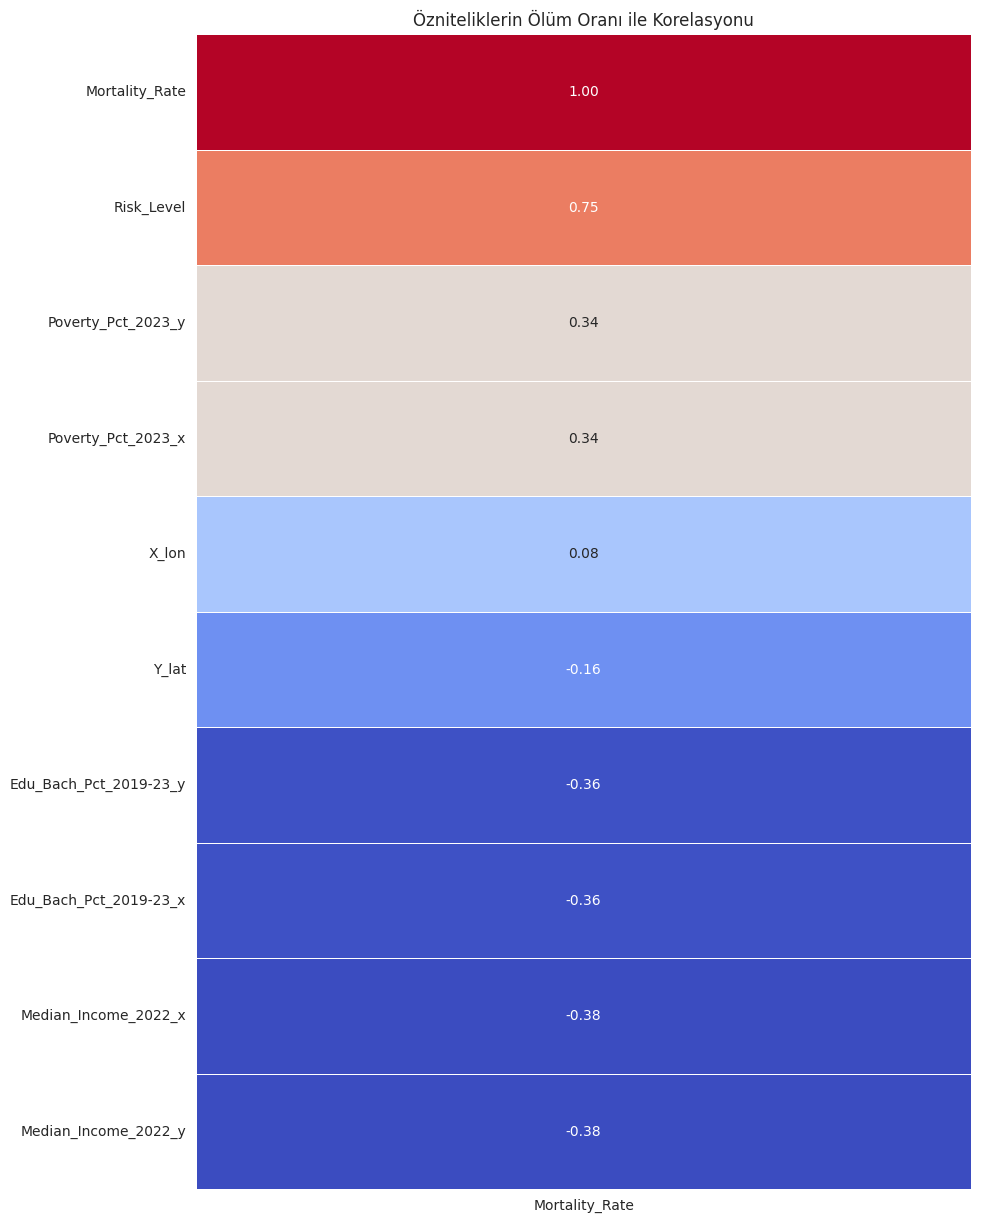

In [12]:
#  Ölçekleme ve Korelasyon Filtresi
# 4. Veri Ölçekleme (StandardScaler)
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)
print("Sayısal öznitelikler başarıyla ölçeklendi (StandardScaler).")

# Korelasyon Hesaplama
y_reset = y.reset_index(drop=True)
X_scaled_reset = X_scaled.reset_index(drop=True)
correlation_matrix = pd.concat([X_scaled_reset, y_reset], axis=1).corr()
target_corr = correlation_matrix['Mortality_Rate'].sort_values(ascending=False)

# Korelasyon Isı Haritası (Görselleştirme)
plt.figure(figsize=(10, 15))
sns.heatmap(target_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=False)
plt.title('Özniteliklerin Ölüm Oranı ile Korelasyonu')
plt.show()


Seçilen Öznitelik Sayısı: 5
Modelde Kullanılan Özellikler: ['X_lon', 'Y_lat', 'Edu_Bach_Pct_2019-23_y', 'Edu_Bach_Pct_2019-23_x', 'Median_Income_2022_y']


/tmp/ipython-input-54633939.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


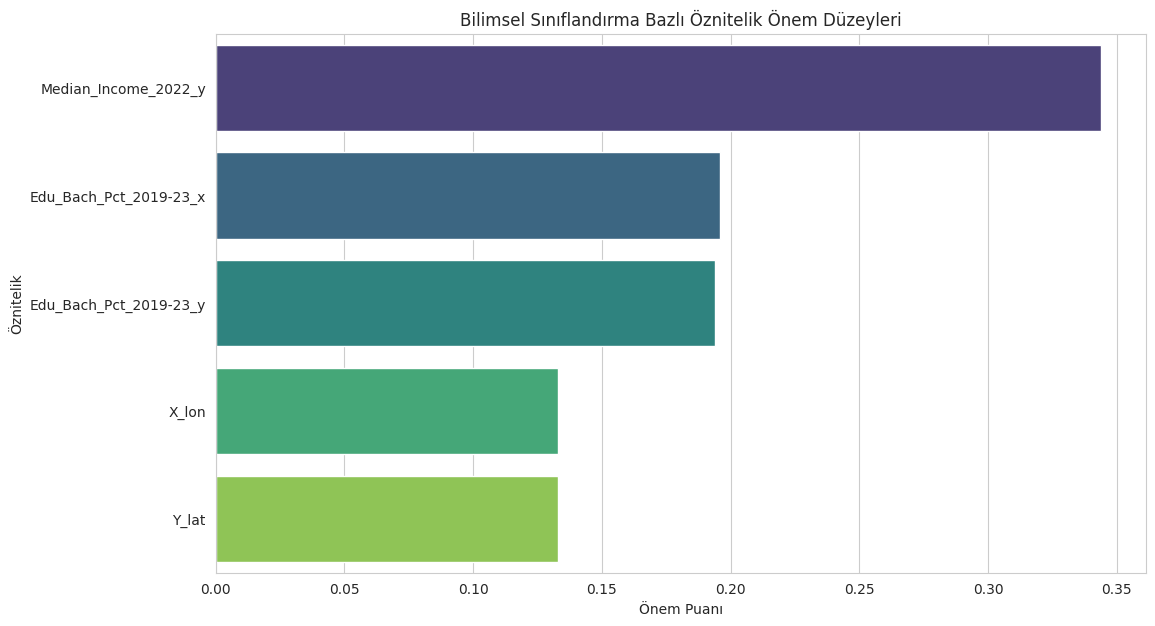


Nihai Öznitelik Kümesi: ['Median_Income_2022_y', 'Edu_Bach_Pct_2019-23_x', 'Edu_Bach_Pct_2019-23_y', 'X_lon', 'Y_lat']
X_final boyutu: (33030, 5)


In [16]:
from sklearn.ensemble import RandomForestClassifier

# 1. Hedef Değişkeni Tanımlama
# Not: df_final_merged içinde 'Risk_Level' sütununu oluşturduğunuzdan emin olun
y = df_final_merged['Risk_Level']

# 2. Korelasyon Analizi (Yeni Bilimsel Gruplara Göre)
# Sadece sayısal sütunları seçip yeni hedef değişkenle korelasyonuna bakıyoruz
numeric_df = df_final_merged.select_dtypes(include=['number'])
target_corr_new = numeric_df.corr()['Risk_Level'].sort_values(ascending=False)

# 3. Öznitelik Seçimi
CORRELATION_THRESHOLD = 0.4
high_corr_features = target_corr_new[abs(target_corr_new) > CORRELATION_THRESHOLD].index.tolist()

# ÖNEMLİ: Modelin hile yapmasını (leakage) önlemek için hedefle doğrudan ilgili sütunları çıkarıyoruz
forbidden_cols = ['Mortality_Rate', 'Risk_Level', 'Risk_Grubu', 'FIPS', 'Poverty_Pct_2023_x', 'Poverty_Pct_2023_y']
high_corr_features = [col for col in high_corr_features if col not in forbidden_cols]

# Eğer korelasyon eşiği çok katıysa ve özellik kalmadıysa en iyi 5 özelliği al
if len(high_corr_features) == 0:
    potential_features = [col for col in target_corr_new.index if col not in forbidden_cols]
    high_corr_features = potential_features[:5]

# Eğitim verisini filtrele (Ölçeklenmiş veri seti X_scaled üzerinden)
X_filtered = X_scaled[high_corr_features]

print(f"\nSeçilen Öznitelik Sayısı: {len(high_corr_features)}")
print(f"Modelde Kullanılan Özellikler: {high_corr_features}")

# 4. Random Forest Sınıflandırıcı Eğitimi
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_filtered, y)

# 5. Önem Puanlarını Hesaplama ve Sıralama
feature_importances = pd.Series(rf_model.feature_importances_, index=X_filtered.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# 6. Görselleştirme
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Bilimsel Sınıflandırma Bazlı Öznitelik Önem Düzeyleri')
plt.xlabel('Önem Puanı')
plt.ylabel('Öznitelik')
plt.show()

# 7. Nihai Özellik Kümesi Seçimi
N_BEST_FEATURES = 10
final_features = feature_importances.head(N_BEST_FEATURES).index.tolist()
X_final = X_scaled[final_features]

print("\nNihai Öznitelik Kümesi:", final_features)
print(f"X_final boyutu: {X_final.shape}")

In [18]:
# Faz 3'e Geçiş (Veri Bölme)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.25, random_state=42, stratify=y
)

print("\n--- FAZ 2 TAMAMLANDI. FAZ 3'E GEÇİLİYOR ---")
print(f"Eğitim Kümesi (X_train) Boyutu: {X_train.shape}")
print(f"Test Kümesi (X_test) Boyutu: {X_test.shape}")


--- FAZ 2 TAMAMLANDI. FAZ 3'E GEÇİLİYOR ---
Eğitim Kümesi (X_train) Boyutu: (24772, 5)
Test Kümesi (X_test) Boyutu: (8258, 5)


In [27]:
# Kütüphane Yükleme ve Temel Veri Hazırlığı
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Sklearn Kütüphaneleri
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# I. VERİ HAZIRLIĞI
FILE_NAME = "tum_veriler_temiz_birlesmis.csv"
df = pd.read_csv(FILE_NAME)

# Gereksiz Sütunları Çıkarma
COLS_TO_DROP_INITIAL = ['State', 'FIPS', 'Georeference', 'Unnamed: 0']
df_model = df.drop(columns=COLS_TO_DROP_INITIAL, errors='ignore')

# --- BİLİMSEL SINIFLANDIRMA GÜNCELLEMESİ ---
def risk_seviyesi(oran):
    if oran < 150:
        return 0  # Düşük Risk
    elif 150 <= oran <= 300:
        return 1  # Orta Risk
    else:
        return 2  # Yüksek Risk

# Bilimsel sınıflandırmayı oluşturuyoruz
df_model['Risk_Class'] = df_model['Mortality_Rate'].apply(risk_seviyesi)

# One-Hot Encoding (Kategorik verileri sayıya çevirme)
df_encoded = pd.get_dummies(df_model, drop_first=True)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

# --- VERİ SIZINTISINI ÖNLEME  ---
# Modelin "kopya" çekebileceği tüm türetilmiş sütunları buradan siliyoruz
forbidden_cols = ['Mortality_Rate', 'Risk_Level', 'Risk_Grubu', 'Risk_Class']

# X: Özellikler (Sadece bağımsız değişkenler)
X = df_encoded.drop(columns=[col for col in forbidden_cols if col in df_encoded.columns])

# y: Hedef (Tahmin edilecek bilimsel sınıflar)
y = df_encoded['Risk_Class']

print(f"Bilimsel Risk Sınıfları (0,1,2) oluşturuldu.")
print(f"Toplam öznitelik sayısı: {X.shape[1]}")
print("Modelin göreceği öznitelikler:", X.columns.tolist()[:10], "... (devamı var)")

Bilimsel Risk Sınıfları (0,1,2) oluşturuldu.
Toplam öznitelik sayısı: 17
Modelin göreceği öznitelikler: ['Y_lat', 'X_lon', 'Median_Income_2022_x', 'Edu_Bach_Pct_2019-23_x', 'Poverty_Pct_2023_x', 'Median_Income_2022_y', 'Edu_Bach_Pct_2019-23_y', 'Poverty_Pct_2023_y', 'Gender_Male', 'Gender_Overall'] ... (devamı var)


In [28]:
# Veri Bölme ve Ölçekleme
# Sınıflandırma modelinde grupların dengeli dağılması için stratify=y ekliyoruz
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler ile ölçekleme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# DataFrame formatına geri dönüştürme (Sütun isimlerini korumak için)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Eğitim Kümesi Boyutu: {X_train_scaled_df.shape}")
print(f"Test Kümesi Boyutu: {X_test_scaled_df.shape}")

Eğitim Kümesi Boyutu: (26424, 17)
Test Kümesi Boyutu: (6606, 17)


In [29]:
# ANOVA Seçimi ve Deney Kurulumu

results = []
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gaussian Naive Bayes": GaussianNB()
}

scenarios = [
    ("Tüm Özellikler", "all"),
    ("Top 14 Özellik (ANOVA)", 14),
    ("Top 10 Özellik (ANOVA)", 10)
]

best_model_results = {}
f_scores_for_plot = None

# Model Eğitim ve Değerlendirme Döngüsü
for scenario_name, k_val in scenarios:

    # Özellik Seçimi (ANOVA Uygulama)
    if k_val == "all":
        X_tr_final = X_train_scaled_df
        X_te_final = X_test_scaled_df
        selected_features = X.columns.tolist()
    else:
        # 3 sınıflı (0,1,2) veride f_classif (ANOVA) kullanımı bilimsel olarak doğrudur
        selector = SelectKBest(score_func=f_classif, k=k_val)
        selector.fit(X_train_scaled_df, y_train)

        cols_idxs = selector.get_support(indices=True)
        X_tr_final = X_train_scaled_df.iloc[:, cols_idxs]
        X_te_final = X_test_scaled_df.iloc[:, cols_idxs]
        selected_features = X_tr_final.columns.tolist()

        if scenario_name == "Top 10 Özellik (ANOVA)":
            f_scores = selector.scores_[cols_idxs]
            f_scores_for_plot = pd.DataFrame({
                'Feature': selected_features,
                'F-Score': f_scores
            }).sort_values(by='F-Score', ascending=False)


    # Modelleri Eğitme ve Değerlendirme
    for model_name, model in models.items():
        start_time = time.time()
        model.fit(X_tr_final, y_train)
        y_pred = model.predict(X_te_final)
        elapsed = time.time() - start_time

        # --- BİLİMSEL SINIFLANDIRMA İÇİN KRİTİK AYAR: average='weighted' ---
        # 3 sınıfın (0,1,2) ortalama başarısını hesaplar
        f1 = f1_score(y_test, y_pred, average='weighted')
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "Senaryo": scenario_name,
            "Model": model_name,
            "Özellik Sayısı": len(selected_features),
            "F1 Score": round(f1, 4),
            "Accuracy": round(acc, 4),
            "Süre (sn)": round(elapsed, 4)
        })

        if f1 > best_model_results.get('F1 Score', 0):
            best_model_results = {
                "F1 Score": f1,
                "y_pred": y_pred,
                "model_name": model_name,
                "scenario_name": scenario_name
            }

# --- ÇIKTIYI GÖRÜNTÜLEME ---
print("DENEYLER ÇALIŞTIRILDI VE SONUÇLAR TOPLANDI")


DENEYLER ÇALIŞTIRILDI VE SONUÇLAR TOPLANDI



--- PERFORMANS TABLOSU ---
                  Senaryo                 Model  Özellik Sayısı  F1 Score  \
0          Tüm Özellikler   Logistic Regression              17    0.8062   
2  Top 14 Özellik (ANOVA)   Logistic Regression              14    0.7534   
4  Top 10 Özellik (ANOVA)   Logistic Regression              10    0.7279   
5  Top 10 Özellik (ANOVA)  Gaussian Naive Bayes              10    0.6693   
3  Top 14 Özellik (ANOVA)  Gaussian Naive Bayes              14    0.6426   
1          Tüm Özellikler  Gaussian Naive Bayes              17    0.6292   

   Accuracy  Süre (sn)  
0    0.8108     2.3511  
2    0.7631     0.7125  
4    0.7440     0.3726  
5    0.6907     0.0148  
3    0.6815     0.0545  
1    0.6589     0.0679  


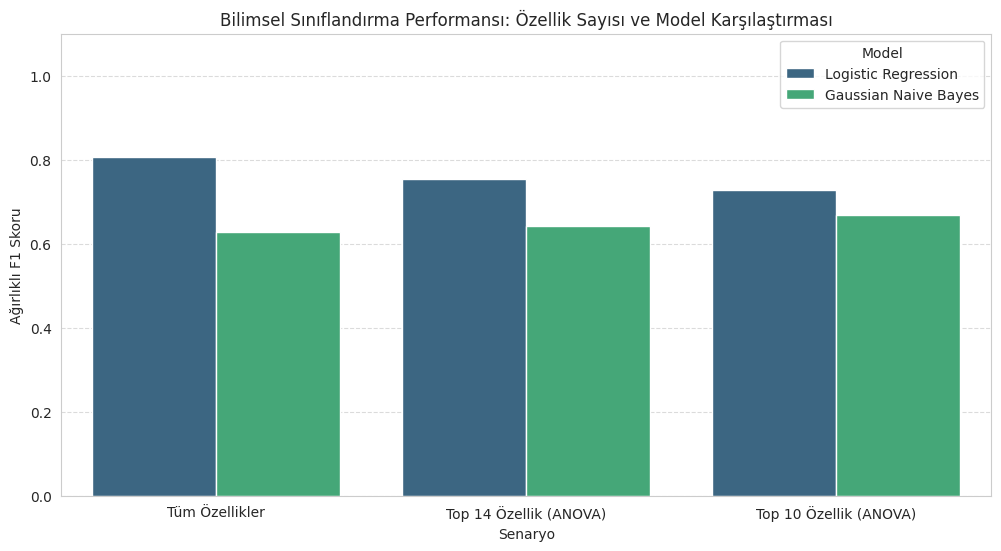

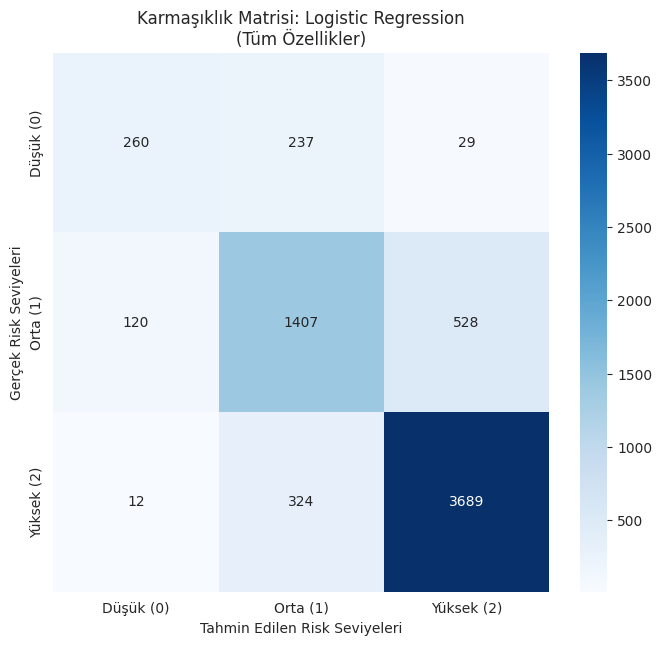

/tmp/ipython-input-1322498724.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F-Score', y='Feature', data=f_scores_for_plot, palette='magma')


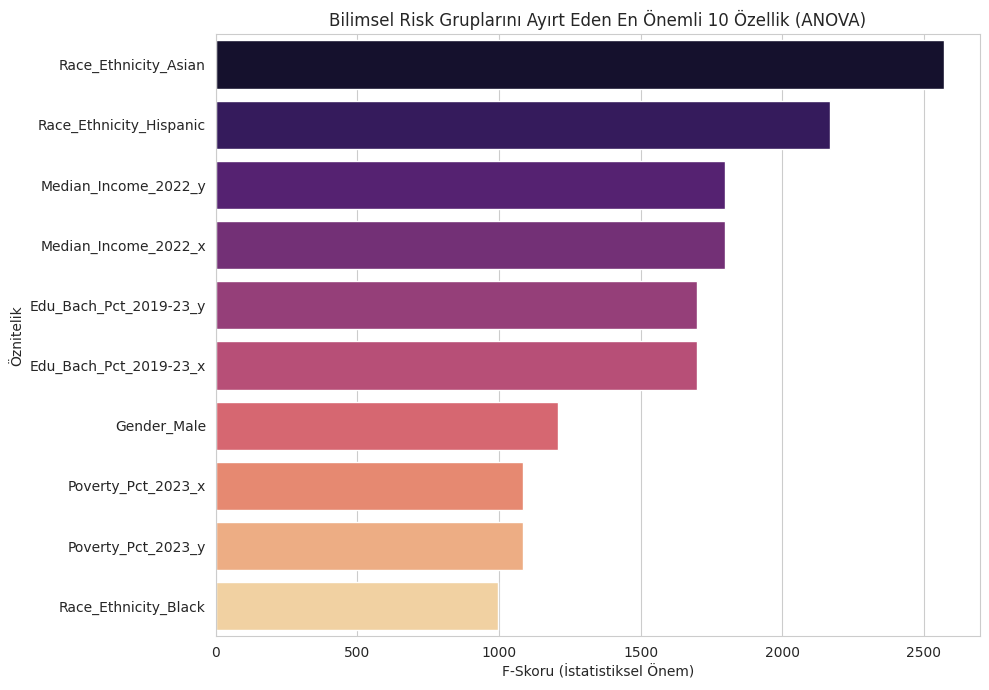


--- FAZ 3 TAMAMLANDI: Tüm Görsel Çıktılar Üretildi ---


In [30]:
# Raporlama ve Görselleştirme
df_results = pd.DataFrame(results)

print("\n--- PERFORMANS TABLOSU ---")
print(df_results.sort_values(by="F1 Score", ascending=False))


# 1. F1 SCORE KARŞILAŞTIRMA GRAFİĞİ
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x="Senaryo", y="F1 Score", hue="Model", palette="viridis")
plt.title("Bilimsel Sınıflandırma Performansı: Özellik Sayısı ve Model Karşılaştırması")
plt.ylim(0, 1.1) # Üst sınırı biraz artırdık
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylabel("Ağırlıklı F1 Skoru")
plt.show()

# 2. EN İYİ MODEL İÇİN KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX)
# Not: 3 sınıfımız olduğu için etiket listesini güncelliyoruz
cm = confusion_matrix(y_test, best_model_results['y_pred'])

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Düşük (0)', 'Orta (1)', 'Yüksek (2)'],
            yticklabels=['Düşük (0)', 'Orta (1)', 'Yüksek (2)'])

plt.title(f"Karmaşıklık Matrisi: {best_model_results['model_name']}\n({best_model_results['scenario_name']})")
plt.ylabel('Gerçek Risk Seviyeleri')
plt.xlabel('Tahmin Edilen Risk Seviyeleri')
plt.show()

# 3. ÖZELLİK ÖNEM GRAFİĞİ (ANOVA F-SKORU) - Sadece Top 10 için
if f_scores_for_plot is not None:
    plt.figure(figsize=(10, 7))
    sns.barplot(x='F-Score', y='Feature', data=f_scores_for_plot, palette='magma')
    plt.title(f"Bilimsel Risk Gruplarını Ayırt Eden En Önemli 10 Özellik (ANOVA)")
    plt.xlabel("F-Skoru (İstatistiksel Önem)")
    plt.ylabel("Öznitelik")
    plt.tight_layout()
    plt.show()

print("\n--- FAZ 3 TAMAMLANDI: Tüm Görsel Çıktılar Üretildi ---")

In [34]:
import torch
import torch.nn as nn
import numpy as np

# 1. Cihaz Tanımlama
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Model şu cihazda çalışacak: {device}")

# 2. Tensör Dönüşümü
X_train_t = torch.tensor(np.array(X_train), dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_t = torch.tensor(np.array(X_test), dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.values, dtype=torch.long).to(device)

Model şu cihazda çalışacak: cpu


In [36]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

# 1. Cihaz Tanımlama
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cihaz: {device}")

# 2. Verilerin Tensöre Dönüştürülmesi
# Not: X_train ve y_train'in önceki adımlarda (stratify=y ile) oluşturulduğundan emin olun.
# Eğer X_train bir DataFrame ise .values veya np.array() ile alıyoruz.
X_train_t = torch.tensor(np.array(X_train), dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.long).to(device)

X_test_t = torch.tensor(np.array(X_test), dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.values, dtype=torch.long).to(device)

# 3. DataLoader Oluşturma
# Batch Size: 64 (Genel standart)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("-" * 30)
print(f"Train Loader Hazır: {len(train_loader)} batch")
print(f"Test Loader Hazır: {len(test_loader)} batch")
print(f"Giriş Boyutu (INPUT_DIM): {X_train_t.shape[1]}")
print("-" * 30)

Cihaz: cpu
------------------------------
Train Loader Hazır: 413 batch
Test Loader Hazır: 104 batch
Giriş Boyutu (INPUT_DIM): 66
------------------------------


Sınıf Dağılımı: {0: 2105, 1: 8218, 2: 16101}
Bilimsel Sınıf Ağırlıkları: [4.18432304 1.07179362 0.54704677]

--- TUNING BAŞLATILIYOR (DeepMLP - Bilimsel Risk Sınıflandırma) ---
Epoch  20/220 | VAL Acc=0.8294 | VAL Weighted-F1=0.8339
Erken Durdurma (Early Stopping). En İyi VAL Weighted-F1=0.8378
Ayarlar={'lr': 0.001, 'dropout': 0.2, 'epochs': 220} -> En İyi VAL F1=0.8378
Epoch  20/260 | VAL Acc=0.8268 | VAL Weighted-F1=0.8318
Epoch  40/260 | VAL Acc=0.8258 | VAL Weighted-F1=0.8311
Epoch  60/260 | VAL Acc=0.8365 | VAL Weighted-F1=0.8398
Erken Durdurma (Early Stopping). En İyi VAL Weighted-F1=0.8422
Ayarlar={'lr': 0.0005, 'dropout': 0.3, 'epochs': 260} -> En İyi VAL F1=0.8422
Epoch  20/320 | VAL Acc=0.7681 | VAL Weighted-F1=0.7798
Epoch  40/320 | VAL Acc=0.7866 | VAL Weighted-F1=0.7960
Epoch  60/320 | VAL Acc=0.8096 | VAL Weighted-F1=0.8155
Epoch  80/320 | VAL Acc=0.8126 | VAL Weighted-F1=0.8186
Epoch 100/320 | VAL Acc=0.8218 | VAL Weighted-F1=0.8267
Erken Durdurma (Early Stopping). En İy

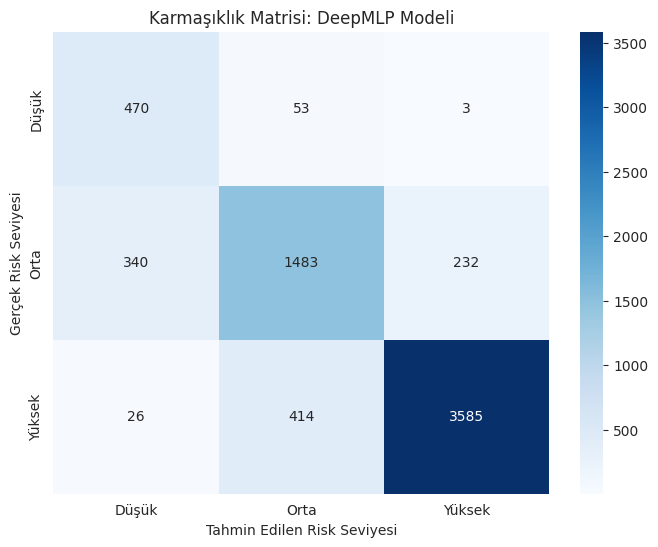

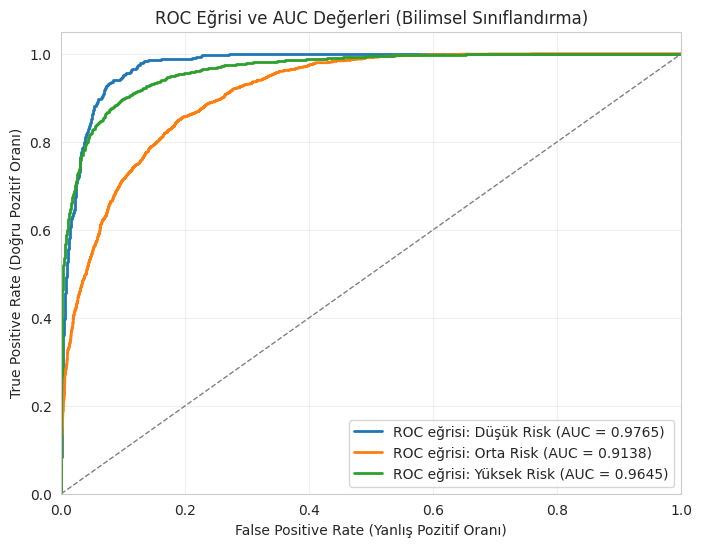

In [37]:
# Model 1 DEEPMLP3
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns # Görselleştirme için eklendi
import random

# Seed sabitleme
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Global Değişkenler
INPUT_DIM = X_train_t.shape[1]
NUM_CLASSES = 3

# ---------- MODEL MİMARİSİ (BİLİMSEL İYİLEŞTİRME) ----------
# Daha sığ (shallow) ama etkili bir ağ yapısı, overfitting'i önler
class DeepMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),  # 256 yerine 128 (Daha verimli)
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ---------- CLASS WEIGHTS  ----------
# Sınıf dengesizliğini matematiksel olarak düzelten ağırlıklar
class_counts = y_train.value_counts().sort_index()
weights = (class_counts.sum() / (NUM_CLASSES * class_counts)).values
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("Sınıf Dağılımı:", class_counts.to_dict())
print("Bilimsel Sınıf Ağırlıkları:", weights)

# ---------- TRAIN / VALIDATE FUNCTION ----------
def train_one(model, lr=1e-3, max_epochs=200, patience=8):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # Ağırlıklı Loss kullanarak azınlık sınıfların ezilmesini önlüyoruz
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_score = -1.0
    best_state = None
    bad = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_test_t)
            val_preds = torch.argmax(val_logits, dim=1).cpu().numpy()
            y_val_np = y_test_t.cpu().numpy()

            val_acc = accuracy_score(y_val_np, val_preds)
            # Bilimsel temel için 'weighted' ortalama kullanıyoruz
            val_f1  = f1_score(y_val_np, val_preds, average="weighted")

        score = val_f1

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d}/{max_epochs} | VAL Acc={val_acc:.4f} | VAL Weighted-F1={val_f1:.4f}")

        if score > best_score + 1e-4:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Erken Durdurma (Early Stopping). En İyi VAL Weighted-F1={best_score:.4f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(device)
    return model, best_score

# ---------- HYPERPARAMETER TUNING ----------
grid = [
    {"lr": 1e-3,  "dropout": 0.2, "epochs": 220},
    {"lr": 5e-4,  "dropout": 0.3, "epochs": 260},
    {"lr": 1e-4,  "dropout": 0.5, "epochs": 320},
]

results = []
best = {"score": -1.0, "cfg": None, "model": None}

print("\n--- TUNING BAŞLATILIYOR (DeepMLP - Bilimsel Risk Sınıflandırma) ---")
for cfg in grid:
    set_seed(42)
    model = DeepMLP(INPUT_DIM, NUM_CLASSES, dropout=cfg["dropout"])
    model, best_val_f1 = train_one(model, lr=cfg["lr"], max_epochs=cfg["epochs"], patience=15) # Patience artırıldı

    results.append({
        "lr": cfg["lr"],
        "dropout": cfg["dropout"],
        "epochs": cfg["epochs"],
        "best_val_f1": best_val_f1
    })

    print(f"Ayarlar={cfg} -> En İyi VAL F1={best_val_f1:.4f}")

    if best_val_f1 > best["score"]:
        best = {"score": best_val_f1, "cfg": cfg, "model": model}

tuning_df = pd.DataFrame(results).sort_values("best_val_f1", ascending=False).reset_index(drop=True)
print("\nTUNING TABLOSU:")
print(tuning_df)

# ---------- TEST SONUÇLARI ----------
best_model = best["model"]
best_model.eval()

with torch.no_grad():
    test_logits = best_model(X_test_t)
    test_probs = torch.softmax(test_logits, dim=1).cpu().numpy()
    y_pred = torch.argmax(test_logits, dim=1).cpu().numpy()

y_test_np = y_test_t.cpu().numpy()

test_acc = accuracy_score(y_test_np, y_pred)
test_f1_weighted = f1_score(y_test_np, y_pred, average="weighted")

print("\nEN İYİ KONFİGÜRASYON:", best["cfg"])
print("--- TEST SONUÇLARI (DeepMLP) ---")
print(f"Accuracy         : {test_acc:.4f}")
print(f"Weighted F1      : {test_f1_weighted:.4f}")

print("\nSınıflandırma Raporu:")
print(classification_report(
    y_test_np,
    y_pred,
    target_names=["Düşük Risk", "Orta Risk", "Yüksek Risk"]
))

# ---------- GÖRSELLEŞTİRME 1: CONFUSION MATRIX (ISI HARİTASI) ----------
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_np, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Düşük", "Orta", "Yüksek"],
            yticklabels=["Düşük", "Orta", "Yüksek"])
plt.title('Karmaşıklık Matrisi: DeepMLP Modeli')
plt.ylabel('Gerçek Risk Seviyesi')
plt.xlabel('Tahmin Edilen Risk Seviyesi')
plt.show()

# ---------- GÖRSELLEŞTİRME 2: ROC EĞRİLERİ ----------
y_test_bin = label_binarize(y_test_np, classes=[0, 1, 2])
target_names = ["Düşük Risk", "Orta Risk", "Yüksek Risk"]

plt.figure(figsize=(8, 6))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC eğrisi: {target_names[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('ROC Eğrisi ve AUC Değerleri (Bilimsel Sınıflandırma)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

 X shape: (33030, 66)
 Sınıf Dağılımı (y):
 Risk_Class
0     2631
1    10273
2    20126
Name: count, dtype: int64

--- TUNING START (RandomForestClassifier) ---
 cfg={'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'max_features': 'sqrt'} -> VAL Acc=0.8444 | VAL Weighted-F1=0.8417
 cfg={'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 2, 'max_features': 'sqrt'} -> VAL Acc=0.8457 | VAL Weighted-F1=0.8450
 cfg={'n_estimators': 400, 'max_depth': 10, 'min_samples_split': 5, 'max_features': 'log2'} -> VAL Acc=0.7799 | VAL Weighted-F1=0.7859

 TUNING TABLE (sorted by VAL Weighted-F1):
   n_estimators  max_depth  min_samples_split max_features  val_accuracy  \
0           400       20.0                  2         sqrt      0.845746   
1           200        NaN                  2         sqrt      0.844384   
2           400       10.0                  5         log2      0.779897   

   val_f1_weighted  
0         0.844961  
1         0.841667  
2         0.785880  

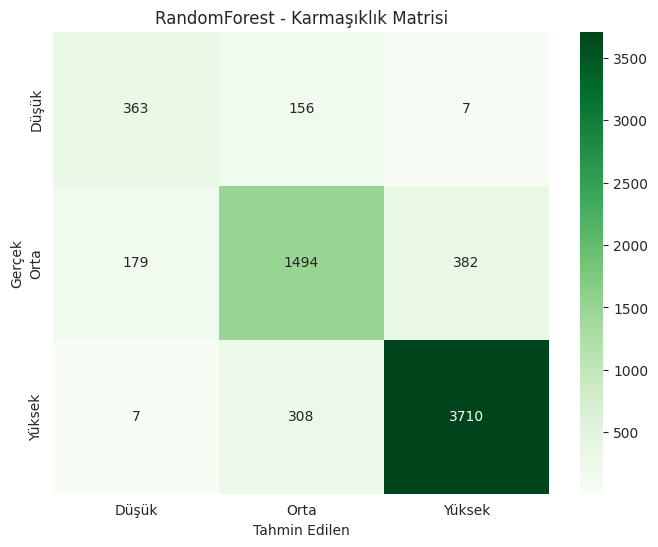


ROC-AUC (Weighted, OvR): 0.9469


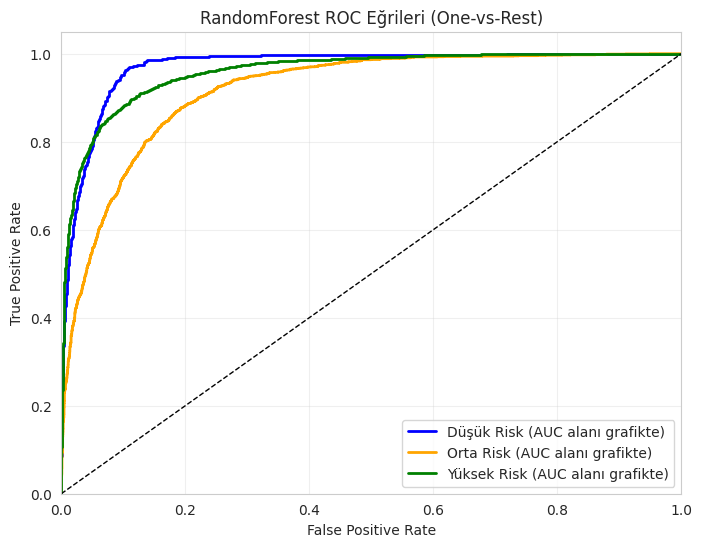

In [38]:
# ===== MODEL 2: RandomForestClassifier (Ensemble) - BİLİMSEL VERSİYON
# Target: Risk_Class (0: Low, 1: Medium, 2: High) - WHO/CDC Standartları

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier

# 1) VERİYİ YÜKLEME
DATA_PATH = "/content/tum_veriler_temiz_birlesmis.csv"
try:
    df = pd.read_csv(DATA_PATH)
except:
    df = pd.read_csv("tum_veriler_temiz_birlesmis.csv")

# 2) BİLİMSEL SINIFLANDIRMA (CRITICAL FIX)
def risk_seviyesi(oran):
    if oran < 150: return 0      # Düşük Risk
    elif 150 <= oran <= 300: return 1 # Orta Risk
    else: return 2               # Yüksek Risk

df["Risk_Class"] = df["Mortality_Rate"].apply(risk_seviyesi)

# 3) ÖZNİTELİK MÜHENDİSLİĞİ VE TEMİZLİK
# Target (y) ve Model Girdisi (X) Ayrımı
y = df["Risk_Class"]

# Veri Sızıntısını Önleme: Hedef değişken ve türevlerini atıyoruz
forbidden_cols = ["Mortality_Rate", "Risk_Class", "Mortality_Class", "Risk_Level", "Georeference", "FIPS", "Unnamed: 0"]
X = df.drop(columns=[c for c in forbidden_cols if c in df.columns], errors="ignore")

# One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=["State", "Gender", "Race_Ethnicity"],
    drop_first=True
)

# Boolean düzeltmesi
for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(int)

print(" X shape:", X.shape)
print(" Sınıf Dağılımı (y):\n", y.value_counts().sort_index())

# 4) VERİ BÖLME (Stratify ile Denge Koruma)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

# Random Forest için ölçekleme (scaling) gerekmez.
X_train_s, X_val_s, X_test_s = X_train, X_val, X_test

# 5) HİPERPARAMETRE OPTİMİZASYONU (Grid Search)
param_grid = [
    {"n_estimators": 200, "max_depth": None, "min_samples_split": 2, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 20,   "min_samples_split": 2, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 10,   "min_samples_split": 5, "max_features": "log2"},
]

results = []
best = {"score": -1, "cfg": None, "model": None}

print("\n--- TUNING START (RandomForestClassifier) ---")
for cfg in param_grid:
    rf = RandomForestClassifier(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_split=cfg["min_samples_split"],
        max_features=cfg["max_features"],
        class_weight="balanced", # Sınıf dengesizliği için kritik
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_s, y_train)

    val_pred = rf.predict(X_val_s)
    val_acc = accuracy_score(y_val, val_pred)
    # Bilimsel tutarlılık için 'weighted' kullanıyoruz
    val_f1_weighted = f1_score(y_val, val_pred, average="weighted")

    results.append({**cfg, "val_accuracy": val_acc, "val_f1_weighted": val_f1_weighted})
    print(f" cfg={cfg} -> VAL Acc={val_acc:.4f} | VAL Weighted-F1={val_f1_weighted:.4f}")

    if val_f1_weighted > best["score"]:
        best = {"score": val_f1_weighted, "cfg": cfg, "model": rf}

tuning_df = pd.DataFrame(results).sort_values("val_f1_weighted", ascending=False).reset_index(drop=True)
print("\n TUNING TABLE (sorted by VAL Weighted-F1):")
print(tuning_df)

# 6) TEST SONUÇLARI
best_model = best["model"]
test_pred = best_model.predict(X_test_s)

test_acc = accuracy_score(y_test, test_pred)
test_f1_weighted = f1_score(y_test, test_pred, average="weighted")
cm = confusion_matrix(y_test, test_pred)

print("\n EN İYİ KONFİGÜRASYON:", best["cfg"])
print("--- TEST SONUÇLARI (RandomForest) ---")
print(f"Accuracy         : {test_acc:.4f}")
print(f"Weighted F1      : {test_f1_weighted:.4f}")

print("\nSınıflandırma Raporu:")
print(classification_report(y_test, test_pred, target_names=["Düşük Risk", "Orta Risk", "Yüksek Risk"]))

# 7) GÖRSELLEŞTİRME: CONFUSION MATRIX (ISI HARİTASI)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Düşük", "Orta", "Yüksek"],
            yticklabels=["Düşük", "Orta", "Yüksek"])
plt.title("RandomForest - Karmaşıklık Matrisi")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.show()

# 8) ROC-AUC EĞRİLERİ (Multiclass)
probs = best_model.predict_proba(X_test_s)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Ortalama AUC Skoru
auc_weighted = roc_auc_score(y_test_bin, probs, multi_class="ovr", average="weighted")
print(f"\nROC-AUC (Weighted, OvR): {auc_weighted:.4f}")

plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']
target_names = ["Düşük Risk", "Orta Risk", "Yüksek Risk"]

for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{target_names[i]} (AUC alanı grafikte)')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('RandomForest ROC Eğrileri (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 XGBoost Grid Search Başlıyor (Bilimsel Sınıflandırma)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

 EN İYİ PARAMETRELER: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
------------------------------
Accuracy         : 0.8677
Weighted F1      : 0.8661
ROC-AUC (Weighted): 0.9586
------------------------------
Sınıflandırma Raporu:
              precision    recall  f1-score   support

  Düşük Risk       0.75      0.67      0.71       526
   Orta Risk       0.80      0.78      0.79      2055
 Yüksek Risk       0.91      0.94      0.93      4025

    accuracy                           0.87      6606
   macro avg       0.82      0.80      0.81      6606
weighted avg       0.87      0.87      0.87      6606



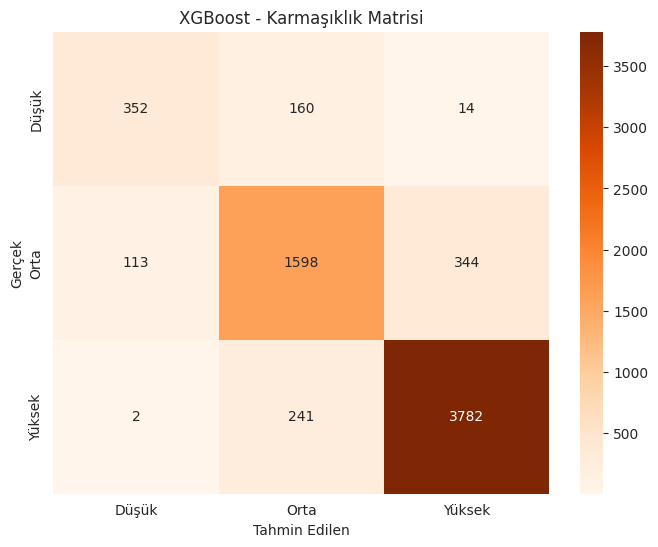

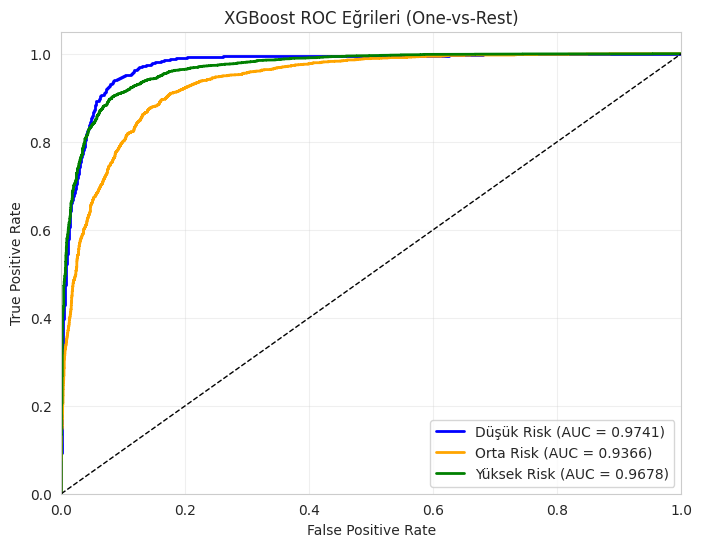

In [39]:
# MODEL 3: XGBOOST (Gradient Boosting)
import pandas as pd
import numpy as np
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, f1_score
import matplotlib.pyplot as plt
import seaborn as sns # Görselleştirme için

# 1. VERİYİ YÜKLEME VE HAZIRLAMA
try:
    df = pd.read_csv('/content/drive/MyDrive/tum_veriler_temiz_birlesmis.csv')
except:
    df = pd.read_csv('tum_veriler_temiz_birlesmis.csv')

# --- BİLİMSEL SINIFLANDIRMA (CRITICAL FIX) ---
# WHO/CDC Standartlarına göre risk seviyeleri
def risk_seviyesi(oran):
    if oran < 150: return 0      # Düşük Risk
    elif 150 <= oran <= 300: return 1 # Orta Risk
    else: return 2               # Yüksek Risk

df['Risk_Class'] = df['Mortality_Rate'].apply(risk_seviyesi)

# Hedef ve Öznitelik Ayrımı
# Veri sızıntısı yapabilecek sütunları temizliyoruz
forbidden_cols = ["Mortality_Rate", "Risk_Class", "Mortality_Class", "Risk_Level", "Georeference", "FIPS", "Unnamed: 0"]
X = df.drop(columns=[c for c in forbidden_cols if c in df.columns], errors='ignore')
y = df["Risk_Class"]

# Kategorik Verileri Dönüştür (One-Hot Encoding)
X = pd.get_dummies(X, columns=["State", "Gender", "Race_Ethnicity"], drop_first=True)

# Boolean değerleri sayıya çevir (XGBoost bazen boolean ile uyarı verebilir)
for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(int)

# Train-Test Split (%80 - %20) - Stratify Önemli
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 2. MODEL TANIMLAMA (XGBoost)
xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# 3. HİPERPARAMETRE OPTİMİZASYONU (Grid Search)
# Diğer modellerle uyumlu olması için scoring='f1_weighted' yapıyoruz
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8]
}

print(" XGBoost Grid Search Başlıyor (Bilimsel Sınıflandırma)...")
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='f1_weighted', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 4. SONUÇLAR
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_probs = best_xgb.predict_proba(X_test)

# Metrikler (Weighted F1 - Diğer modellerle kıyaslanabilir olması için)
test_acc = accuracy_score(y_test, y_pred)
test_f1_weighted = f1_score(y_test, y_pred, average='weighted')
roc_auc_weighted = roc_auc_score(y_test, y_probs, multi_class='ovr', average='weighted')

print("\n EN İYİ PARAMETRELER:", grid_search.best_params_)
print("-" * 30)
print(f"Accuracy         : {test_acc:.4f}")
print(f"Weighted F1      : {test_f1_weighted:.4f}")
print(f"ROC-AUC (Weighted): {roc_auc_weighted:.4f}")
print("-" * 30)

print("Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=["Düşük Risk", "Orta Risk", "Yüksek Risk"]))

# ---------- GÖRSELLEŞTİRME 1: CONFUSION MATRIX (ISI HARİTASI) ----------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Düşük", "Orta", "Yüksek"],
            yticklabels=["Düşük", "Orta", "Yüksek"])
plt.title('XGBoost - Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.show()

# ---------- GÖRSELLEŞTİRME 2: ROC CURVE ----------
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3
colors = ['blue', 'orange', 'green']
class_labels = ["Düşük Risk", "Orta Risk", "Yüksek Risk"]

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{class_labels[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Eğrileri (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Bağlantı kontrol ediliyor
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dosya başarıyla bulundu: /content/drive/MyDrive/tum_veriler_temiz_birlesmis.csv

 KALP KRİZİ RİSKİ (WHO STANDARDI) EN YÜKSEK 10 EYALET:
State
MS    0.945912
WV    0.877108
KY    0.859918
AL    0.842776
AR    0.839018
OK    0.806159
TN    0.804777
LA    0.794203
MO    0.756276
GA    0.743772
Name: Yüksek, dtype: float64


/tmp/ipython-input-791020693.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_15.index, y=top_15.values, palette="Reds_r")


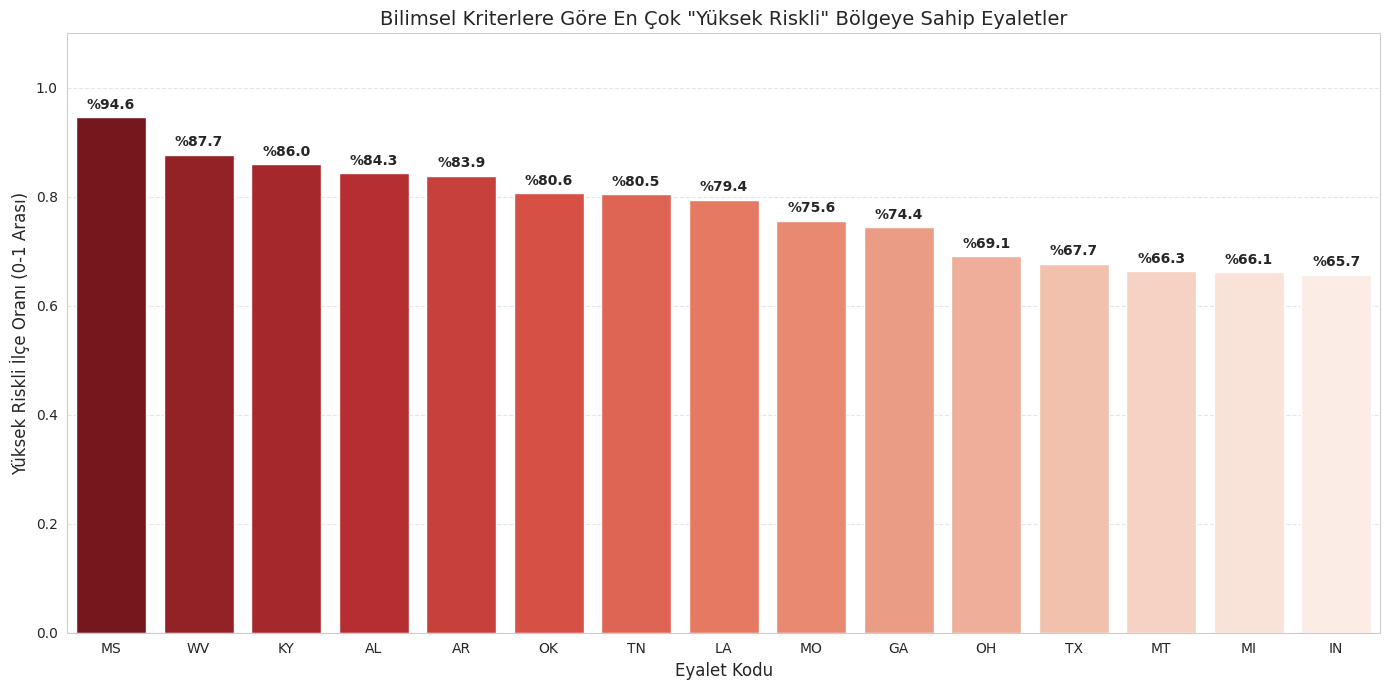

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

print("Bağlantı kontrol ediliyor")
drive.mount('/content/drive')

dosya_yolu = "/content/drive/MyDrive/tum_veriler_temiz_birlesmis.csv"

if os.path.exists(dosya_yolu):
    print(f"Dosya başarıyla bulundu: {dosya_yolu}")

    # Veriyi Oku
    df = pd.read_csv(dosya_yolu)

    # --- KRİTİK DÜZELTME: BİLİMSEL SINIFLANDIRMA ---
    # qcut yerine modellerde kullandığımız aynı mantığı kullanıyoruz
    def risk_seviyesi_etiket(oran):
        if oran < 150:
            return 'Düşük'
        elif 150 <= oran <= 300:
            return 'Orta'
        else:
            return 'Yüksek'

    df['Risk_Level'] = df['Mortality_Rate'].apply(risk_seviyesi_etiket)

    # Eyaletlere göre risk oranlarını hesapla (normalize='index' satır bazlı oran verir)
    eyalet_riski = pd.crosstab(df['State'], df['Risk_Level'], normalize='index')

    # Eğer veri setinde hiç "Yüksek" riskli yer yoksa hata almamak için kontrol
    if 'Yüksek' in eyalet_riski.columns:
        # En yüksek riskli eyaletleri sırala
        en_riskli_eyaletler = eyalet_riski['Yüksek'].sort_values(ascending=False)

        print("\n KALP KRİZİ RİSKİ (WHO STANDARDI) EN YÜKSEK 10 EYALET:")
        print(en_riskli_eyaletler.head(10))

        # 4. Grafiği Çiz
        plt.figure(figsize=(14, 7))
        top_15 = en_riskli_eyaletler.head(15)

        # Görselleştirme
        ax = sns.barplot(x=top_15.index, y=top_15.values, palette="Reds_r")

        plt.title('Bilimsel Kriterlere Göre En Çok "Yüksek Riskli" Bölgeye Sahip Eyaletler', fontsize=14)
        plt.xlabel('Eyalet Kodu', fontsize=12)
        plt.ylabel('Yüksek Riskli İlçe Oranı (0-1 Arası)', fontsize=12)
        plt.ylim(0, 1.1) # Üst boşluk

        # Barların üzerine oranları yaz
        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'%{p.get_height()*100:.1f}',
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center',
                            xytext=(0, 9),
                            textcoords='offset points',
                            fontsize=10, fontweight='bold')

        plt.tight_layout()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.show()
    else:
        print("Veri setinde bilimsel eşiğe (300+) göre 'Yüksek Risk' grubuna giren bölge bulunamadı.")

else:
    print(f" HATA: '{dosya_yolu}' bulunamadı.")